# 09 - Model Explainability (Feature Importance & SHAP)

## Objective

The baseline Random Forest was selected as the final production model after comparing it with the tuned model and the SMOTE-based model. In this notebook, we will interpret the selected model using Feature Importance and SHAP to understand which machine parameters influence predictions and explain individual machine failure predictions.

In [1]:
# Import the required libraries for model explainability and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

c:\Users\carol\Projects\Predictive-Maintenance-Intelligence-Platform\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the engineered dataset that was used to train the final machine learning model.
df = pd.read_csv("../data/processed/engineered_data.csv")

preprocessor = joblib.load("../artifacts/preprocessor.pkl")

df.head()

,Date,System,Control,Type,Air temperature (K),Process temperature (K),Rotational speed (rpm),Torque (Nm),Tool wear (min),Diagnostic,Year,Month,Day,Day_of_Week,Quarter,Temperature_Difference,Power_Index
0,2014-04-15 11:56:00,0,C,M,300.064358,310.033081,1541.242402,42.8,0.00000,No failure,2014,4,15,1,2,9.968723,65965.174787
1,2014-04-12 16:09:00,0,A,L,298.200000,308.700000,1408.000000,39.9,110.52424,No failure,2014,4,12,5,2,10.500000,56179.200000
2,2014-04-13 01:13:00,0,A,L,298.100000,308.500000,1498.000000,39.9,110.52424,No failure,2014,4,13,6,2,10.400000,59770.200000
3,2014-07-24 20:35:00,0,B,L,300.064358,310.033081,1433.000000,39.5,110.52424,No failure,2014,7,24,3,3,9.968723,56603.500000
4,2014-07-22 01:31:00,0,C,L,300.064358,310.033081,1541.242402,40.0,9.00000,No failure,2014,7,22,1,3,9.968723,61649.696062


In [ ]:
# Separate the features and target variable for model training.

X = df.drop(columns=["Diagnostic"])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Diagnostic"])

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (10000, 15)
Target Shape: (10000,)


In [4]:
# Split the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

Training Features: (8000, 15)
Testing Features : (2000, 15)


In [5]:
# Apply the saved preprocessing pipeline to the training and testing datasets.
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape :", X_test_processed.shape)

Processed Training Shape: (8000, 138)
Processed Testing Shape : (2000, 138)


In [6]:
# Train the final Baseline Random Forest model.
baseline_rf = RandomForestClassifier(
    random_state=42
)

baseline_rf.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [7]:
# Extract the feature importance scores from the trained Random Forest model.
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": baseline_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
11,num__Power_Index,0.190187
3,num__Torque (Nm),0.133400
2,num__Rotational speed (rpm),0.122320
4,num__Tool wear (min),0.101183
10,num__Temperature_Difference,0.077236
5,num__Year,0.051571
7,num__Day,0.037313
6,num__Month,0.027936
8,num__Day_of_Week,0.027234
0,num__Air temperature (K),0.026643


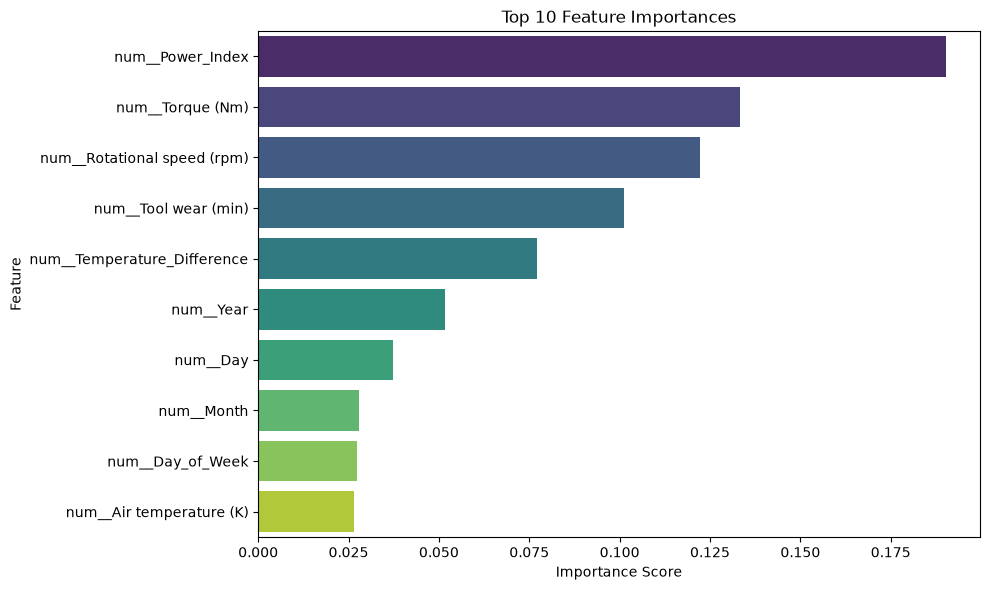

In [8]:
# Visualize the top 10 most important features identified by the Random Forest model.


plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Observations

- **Power Index** is the most important feature for predicting machine failures.
- **Torque**, **Rotational Speed**, and **Tool Wear** also have a strong influence on the model.
- Engineered features like **Power Index** and **Temperature Difference** contribute significantly to the predictions.
- Time-based features have relatively lower importance compared to sensor-based features.

In [9]:
# Convert sparse matrices to dense arrays for SHAP.

X_train_dense = X_train_processed.toarray()
X_test_dense = X_test_processed.toarray()

In [10]:
# Create a SHAP explainer for the trained Random Forest model.

explainer = shap.Explainer(
    baseline_rf,
    X_train_dense
)

In [11]:
# Calculate SHAP values for the test dataset.

shap_values = explainer(
    X_test_dense,
    check_additivity=False
)

100%|===================| 11989/12000 [01:19<00:00]        

In [12]:
print(type(shap_values))
print(shap_values.values.shape)

<class 'shap._explanation.Explanation'>
(2000, 138, 6)


In [17]:
# Create a SHAP Explanation with feature names.

shap_values_named = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=X_test_dense,
    feature_names=feature_names
)

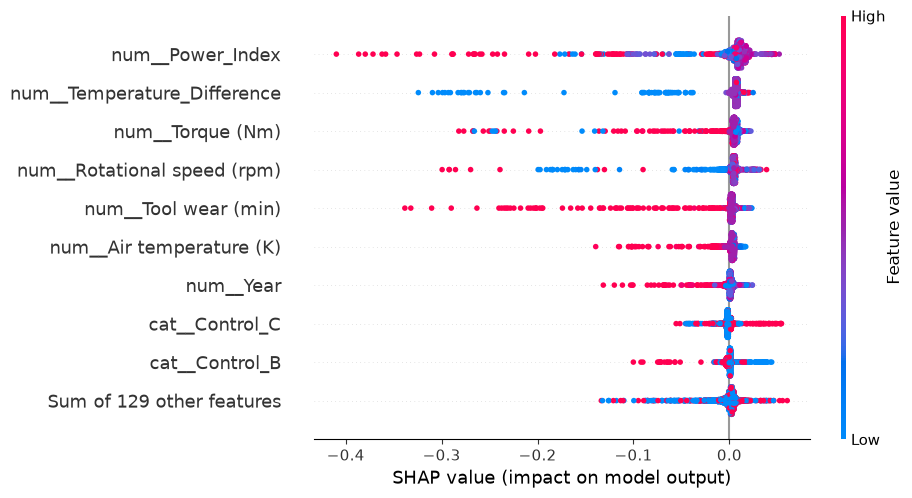

In [21]:
# Display the overall impact of features on model predictions.
shap.plots.beeswarm(shap_values_named[:, :, 1], max_display=10)

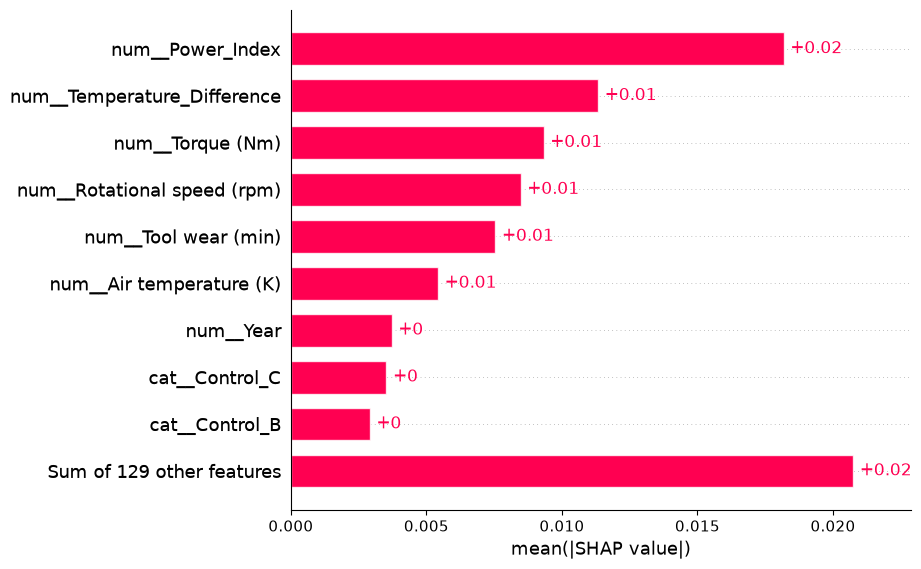

In [22]:
# Display the average importance of features using SHAP values.
shap.plots.bar(shap_values_named[:, :, 1], max_display=10)

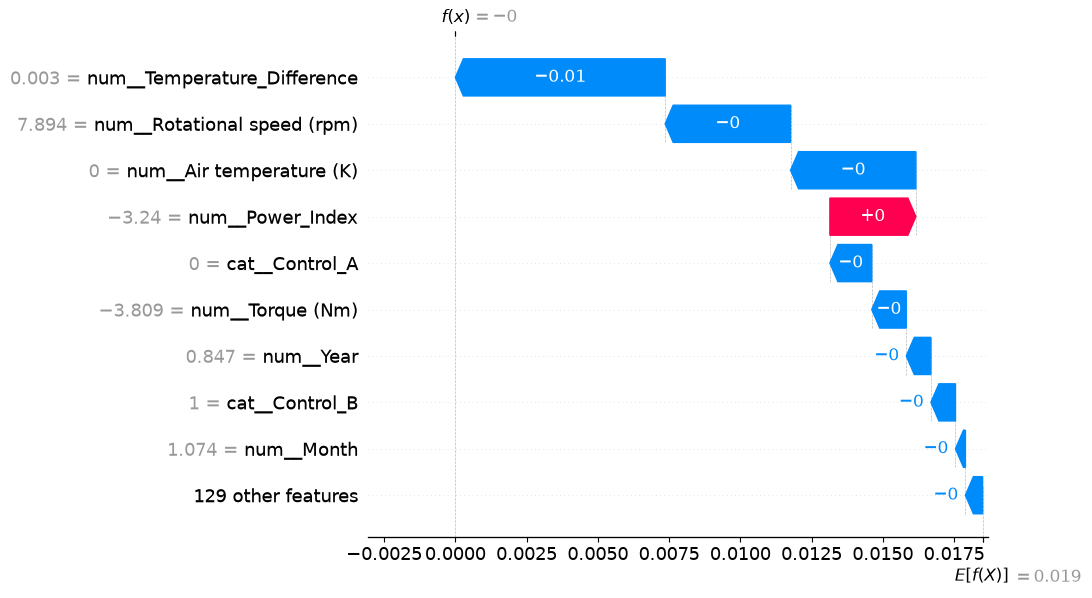

In [20]:
# Explain the prediction for a single machine.
shap.plots.waterfall(shap_values_named[0, :, 0])

In [16]:
print(label_encoder.classes_)

['Heat Dissipation Failure' 'No failure' 'Overstrain Failure'
 'Power Failure' 'Random Failures' 'Tool Wear Failure']


## Observations

- Power Index has the greatest impact on the model's predictions.
- Temperature Difference, Torque, Rotational Speed, and Tool Wear are also influential features.
- SHAP explains how each feature contributes to individual predictions, improving model interpretability.
- The SHAP results align with the Feature Importance analysis, increasing confidence in the model.